# Transformaciones en $\mathbf{P2}$

### Escalado

Podemos estirar o comprimir coordenadas en cada eje usando un factor de escala.

$ p2 = S . p1 $

$
S = \begin{bmatrix}
    s_x & 0 & 0 \\
    0 & s_y & 0 \\
    0 & 0 & 1 \\
\end{bmatrix}
$

### Rotación

Podemos rotar las coordenadas dado el ángulo $θ$.

$ p_2 = R . p_1 $

$
R = \begin{bmatrix}
    cos(θ) & -sin(θ) & 0 \\
    sin(θ) & cos(θ) & 0 \\
    0 & 0 & 1 \\
\end{bmatrix}
$

### Skew

Skew deforma rectángulos en paralelogramos.

$ p_2 = M . p_1 $

$
M = \begin{bmatrix}
    1 & m_x & 0 \\
    m_y & 1 & 0 \\
    0 & 0 & 1 \\
\end{bmatrix}
$

### Traslación

Una translación permite desplazar las coordenadas en x y en y.

$ p_2 = T . p_1 $

$
T = \begin{bmatrix}
    1 & 0 & t_x \\
    0 & 1 & t_y \\
    0 & 0 & 1 \\
\end{bmatrix}
$

## Isometrías

Las isometrías tienen la forma:

$
Iso = \begin{bmatrix}
    R & t \\
    0 & 1 \\
\end{bmatrix}  = \begin{bmatrix}
    cos(θ) & -sin(θ) & t_x \\
    sin(θ) & cos(θ) & t_y \\
    0 & 0 & 1 \\
\end{bmatrix}
$

## Similaridades

Las similaridades tienen la forma:

$
Sim =  \begin{bmatrix}
    \lambda \, R & t \\
    0 & 1 \\
\end{bmatrix}  = \begin{bmatrix}
    \lambda \, cos(θ) & - \lambda \, sin(θ) & t_x \\
    \lambda \, sin(θ) & \lambda \, cos(θ) & t_y \\
    0 & 0 & 1 \\
\end{bmatrix}
$

## Afinidades

Las tranformaciones afines en general tienen la forma:

$
A = \begin{bmatrix}
    a_{11} & a_{12} & a_{13} \\
    a_{21} & a_{22} & a_{23} \\
    0 & 0 & 1 \\
\end{bmatrix}
$

## Homografías

$
H = \begin{bmatrix}
    h_{11} & h_{12} & h_{13} \\
    h_{21} & h_{22} & h_{23} \\
    h_{31} & h_{32} & h_{33} \\
\end{bmatrix}
$

## Propiedades

$ Iso \subset Sim \subset A \subset H $

| Propiedad | Isometría | Similaridad | Afinidad | Homografía |
|---|---|---|---|---|
| Distancias | ✓ | ✗ | ✗ | ✗ |
| Ángulos | ✓ | ✓ | ✗ | ✗ |
| Paralelismo | ✓ | ✓ | ✓ | ✗ |
| Rectas -> rectas | ✓ | ✓ | ✓ | ✓ |
| Razón de segmentos | ✓ | ✓ | ✗ | ✗ |
| Cross ratio | ✓ | ✓ | ✓ | ✓ |


| Transformación | Propiedad clave | DOF | Pares mínimos |
|---|---|---|---|
| Isometría | Preserva distancias | 3 | 2 |
| Similaridad | Preserva ángulos | 4 | 2 |
| Afinidad | Preserva paralelismo | 6 | 3 |
| Homografía | Preserva rectas | 8 | 4 |

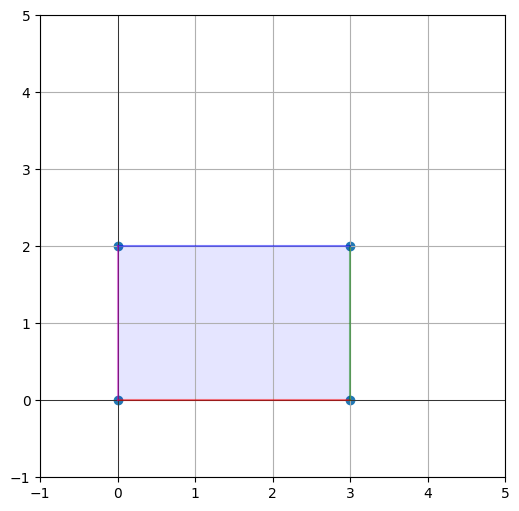

In [5]:
import numpy as np
from homo_utils import plot_shape, homo, cart, apply_transform
from matplotlib import pyplot as plt

ori = np.array([
  (0, 0),
  (3, 0),
  (3, 2),
  (0, 2)
])

plt.figure(figsize=(6, 6))
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plot_shape(ori)
plt.grid()
plt.xlim(-1, 5)
plt.ylim(-1, 5)


plt.show()

In [10]:
angle = 45
theta = np.pi * angle / 180.0
t = (2, 1)

Iso = np.array([
    [np.cos(theta), -np.sin(theta), t[0]],
    [np.sin(theta), np.cos(theta), t[1]],
    [0, 0, 1]
])


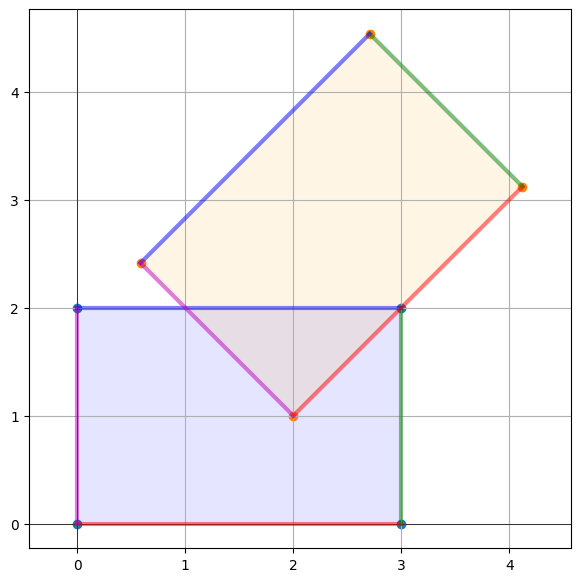

In [11]:
dst = apply_transform(ori, Iso)

plt.figure(figsize=(7, 7))
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plot_shape(ori, w=3, fill='blue')
plot_shape(dst, w=3, fill='orange')
plt.axis('equal')
#plt.xlim(-, 4)
plt.grid()
plt.show()

In [17]:
angle = 45
theta = np.pi * angle / 180.0
t = (2, 1)
s = 0.5

Sim = np.array([
    [s * np.cos(theta), s * -np.sin(theta), t[0]],
    [s * np.sin(theta), s * np.cos(theta), t[1]],
    [0, 0, 1]
])


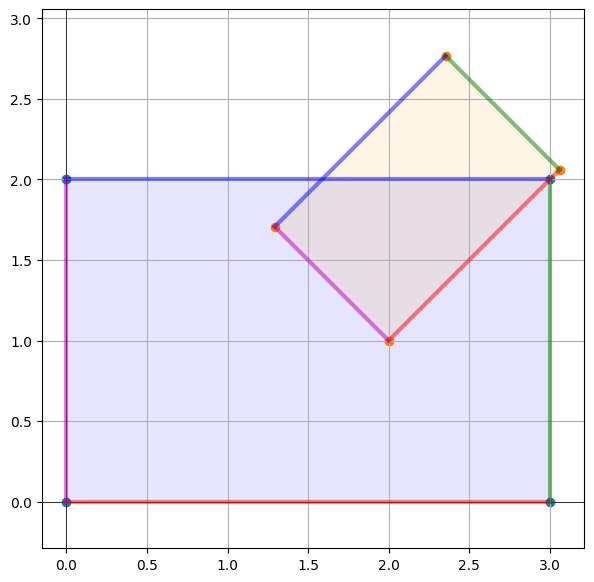

In [18]:
dst = apply_transform(ori, Sim)

plt.figure(figsize=(7, 7))
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plot_shape(ori, w=3, fill='blue')
plot_shape(dst, w=3, fill='orange')
plt.axis('equal')
#plt.xlim(-, 4)
plt.grid()
plt.show()

# Estimando Isometrías

Supongamos que tenemos los pares de correspondencias:

- $ p_1 = (x_1, y_1) \to p'_1 = (x'_1, y'_1) $ 
- $ p_2 = (x_2, y_2) \to p'_2 = (x'_2, y'_2) $ 


Armemos los vectores entre los puntos según:

$
v = 
\begin{bmatrix}
    x_2 - x_1 \\
    y_2 - y_1 \\
\end{bmatrix} 
$  (En el plano original)

$v' = 
\begin{bmatrix}
    x'_2 - x'_1 \\
    y'_2 - y'_1 \\
\end{bmatrix} 
$  (En el plano transformado)


La isometría cumple que:

$v' = R . v $

en donde:

$ R =  \begin{bmatrix}
    cos(θ) & -sin(θ) \\
    sin(θ) & cos(θ) \\
\end{bmatrix}
$

Para hallar $R$ podemos usar:

$ 
    cos(\theta) = \frac{v \cdot v'}{||v|| \, ||v'||}
$

$
    sin(\theta) = \frac{det(v, v')}{||v|| \, ||v'||}
$

Luego:

$
\widetilde{p'_i} = Iso \cdot \widetilde{p_i}
$

$
\begin{bmatrix}
    x'_i \\
    y'_i \\
    1 \\
\end{bmatrix} 
=
\begin{bmatrix}
    cos(θ) & -sin(θ) & t_x \\
    sin(θ) & cos(θ) & t_y \\
    0 & 0 & 1 \\
\end{bmatrix}
.
\begin{bmatrix}
    x_i \\
    y_i \\
    1 \\
\end{bmatrix} 
$

$ 
\begin{cases}
    x_i . cos(\theta) - y_i . sin(\theta) + t_x = x'_i \\
    x_i . sin(\theta) + y_i . cos(\theta) + t_y = y'_i \\
\end{cases}
$

Despejamos $t_x$ y $t_y$:

$ 
\begin{cases}
    t_x = x'_i - (x_i . cos(\theta) - y_i . sin(\theta)) \\
    t_y = y'_i - (x_i . sin(\theta) + y_i . cos(\theta))
\end{cases}
$

Obs: Los vectores $v$ y $v'$ determinan la rotación $R$.
Una vez conocida la rotación, un solo punto correspondiente determina la traslación $t$.

En forma vectorial:

$ t = p'_1 - R p_1 $


# Repaso Trigonometría

Dados dos vectores $u$ y $v$ en $\mathbb{R}^2$:


$$ cos(\theta) = \frac{u \cdot v}{||u|| \, ||v||} $$




$$ sin(\theta) = \frac{det(u, v)}{||u|| \, ||v||} $$

## Seno del ángulo y determinante

El determinante se define como:

$ det(u, v) = \begin{vmatrix}
    u_x & v_x \\
    u_y & v_y \\
\end{vmatrix} = u_x v_y - u_y v_x
$

**Propiedad**
El signo del determinante determina el sentido del giro en $\mathbb{R}^2$

- Si $ det(u, v) < 0 $, giro horario
- Si $ det(u, v) = 0 $, vectores colineales
- Si $ det(u, v) > 0 $, giro antihorario


**Propiedades geométricas** 

El área $A$ del paralelogramo generado por $u,v$ 

1. Coincide con el módulo del determinante.
2. Se puede calcular como el producto de los módulos por el seno del ángulo entre los vectores.

$ A = | det(u, v) | = ||u|| . ||v|| . | sin(\theta) | $

Pero usando el ángulo orientado $\theta \in (-\pi, \pi]$, vale que:

$ det(u, v) = ||u|| . ||v|| . sin(\theta) $

Entonces:

$$ sin(\theta) = \frac{det(u, v)}{||u|| \, ||v||} $$



In [19]:
ori

array([[0, 0],
       [3, 0],
       [3, 2],
       [0, 2]])

In [64]:
angle = 45
theta = np.pi * angle / 180.0
t = (2, 1)

Iso = np.array([
    [np.cos(theta), -np.sin(theta), t[0]],
    [np.sin(theta), np.cos(theta), t[1]],
    [0, 0, 1]
])


In [65]:
dst = apply_transform(ori, Iso)

In [47]:
def estimate_iso(ori, dst, i, j):

    p1 = ori[i]
    q1 = dst[i]
    
    p2 = ori[j]
    q2 = dst[j]

    u = p2 - p1
    v = q2 - q1

    dot = u @ v
    det = u[0] * v[1] - u[1] * v[0]

    nu = np.linalg.norm(u)
    nv = np.linalg.norm(v)
    nuv = 1.0 / (nu * nv)
        
    R = nuv * np.array([
        [dot, -det],
        [det, dot],
    ])

    t = q1 - R @ p1

    ret = np.eye(3)
    ret[:2,:2] = R
    ret[:2,2] = t

    return ret


In [48]:
Iso2 = estimate_iso(ori, dst, 0, 1)

In [49]:
Iso - Iso2

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [56]:
angle = 45
theta = np.pi * angle / 180.0
t = (2, 1)
s = 33

Sim = np.array([
    [s * np.cos(theta), s * -np.sin(theta), t[0]],
    [s * np.sin(theta), s * np.cos(theta), t[1]],
    [0, 0, 1]
])


In [57]:
dst = apply_transform(ori, Sim)

In [68]:

def estimate_sim(ori, dst, i, j):

    p1 = ori[i]
    q1 = dst[i]
    
    p2 = ori[j]
    q2 = dst[j]

    u = p2 - p1
    v = q2 - q1

    dot = u @ v
    det = u[0] * v[1] - u[1] * v[0]

    nu = np.linalg.norm(u)
    nv = np.linalg.norm(v)

    # A = lambda R        
    A = np.array([
        [ dot, -det],
        [ det,  dot],
    ]) / (u @ u)

    t = q1 - A @ p1

    ret = np.eye(3)
    ret[:2,:2] = A
    ret[:2,2] = t

    return ret

In [69]:
estimate_sim(ori, dst, 0, 1)

array([[ 0.70710678, -0.70710678,  2.        ],
       [ 0.70710678,  0.70710678,  1.        ],
       [ 0.        ,  0.        ,  1.        ]])